In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Load dataset 
df = pd.read_csv("heart_attack_prediction_india.csv")

# Show basic info
display(df.head())
print(df.info())



,Patient_ID,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk
0,1,Rajasthan,42,Female,0,0,1,1,0,0,...,119,1,0,4,0,0,157,611025,0,0
1,2,Himachal Pradesh,26,Male,0,0,0,0,1,1,...,115,0,0,7,0,0,331,174527,0,0
2,3,Assam,78,Male,0,0,1,0,0,1,...,117,0,1,10,1,0,186,1760112,1,0
3,4,Odisha,58,Male,1,0,1,0,0,1,...,65,0,0,1,1,1,324,1398213,0,0
4,5,Karnataka,22,Male,0,0,0,0,0,1,...,109,0,0,9,0,0,209,97987,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Patient_ID               10000 non-null  int64 
 1   State_Name               10000 non-null  object
 2   Age                      10000 non-null  int64 
 3   Gender                   10000 non-null  object
 4   Diabetes                 10000 non-null  int64 
 5   Hypertension             10000 non-null  int64 
 6   Obesity                  10000 non-null  int64 
 7   Smoking                  10000 non-null  int64 
 8   Alcohol_Consumption      10000 non-null  int64 
 9   Physical_Activity        10000 non-null  int64 
 10  Diet_Score               10000 non-null  int64 
 11  Cholesterol_Level        10000 non-null  int64 
 12  Triglyceride_Level       10000 non-null  int64 
 13  LDL_Level                10000 non-null  int64 
 14  HDL_Level                10000 non-null

# 1️⃣ CREATE YEAR COLUMN (2010–2024)

In [21]:

years = np.arange(2010, 2025)  # 2010 to 2024 inclusive
df["Year"] = np.random.choice(years, size=len(df), replace=True)

display(df.head())

,Patient_ID,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,...,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk,Year
0,1,Rajasthan,42,Female,0,0,1,1,0,0,...,1,0,4,0,0,157,611025,0,0,2021
1,2,Himachal Pradesh,26,Male,0,0,0,0,1,1,...,0,0,7,0,0,331,174527,0,0,2017
2,3,Assam,78,Male,0,0,1,0,0,1,...,0,1,10,1,0,186,1760112,1,0,2012
3,4,Odisha,58,Male,1,0,1,0,0,1,...,0,0,1,1,1,324,1398213,0,0,2018
4,5,Karnataka,22,Male,0,0,0,0,0,1,...,0,0,9,0,0,209,97987,0,1,2017


# 2️⃣ YEAR-WISE RECORD COUNT

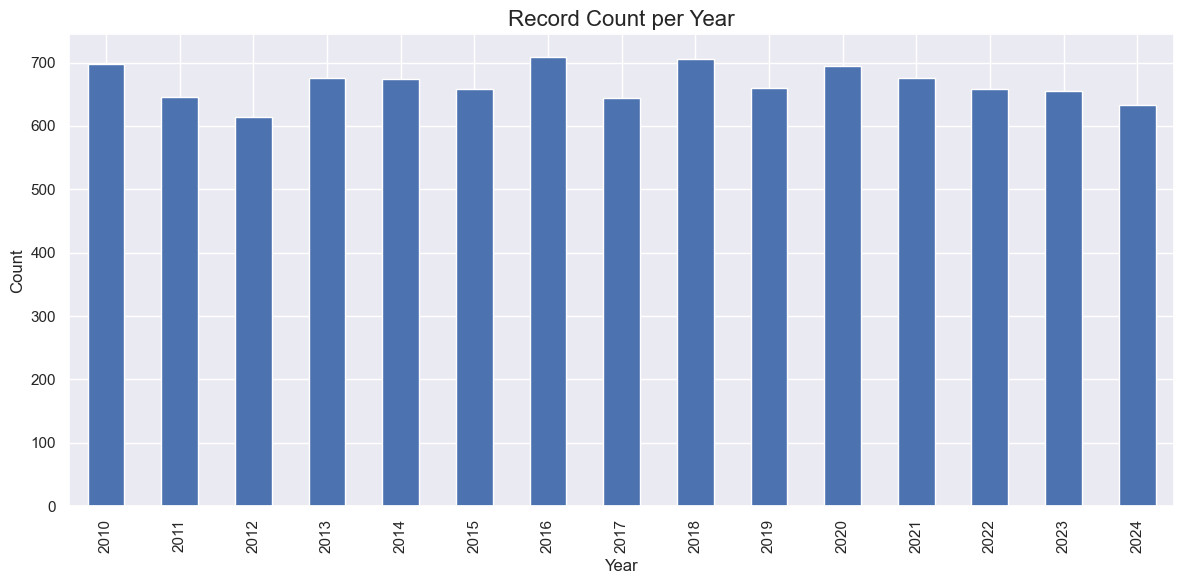

In [24]:
plt.figure(figsize=(12,6))
df["Year"].value_counts().sort_index().plot(kind="bar")
plt.title("Record Count per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3️⃣ YEAR-WISE AVERAGE HEART ATTACK RISK

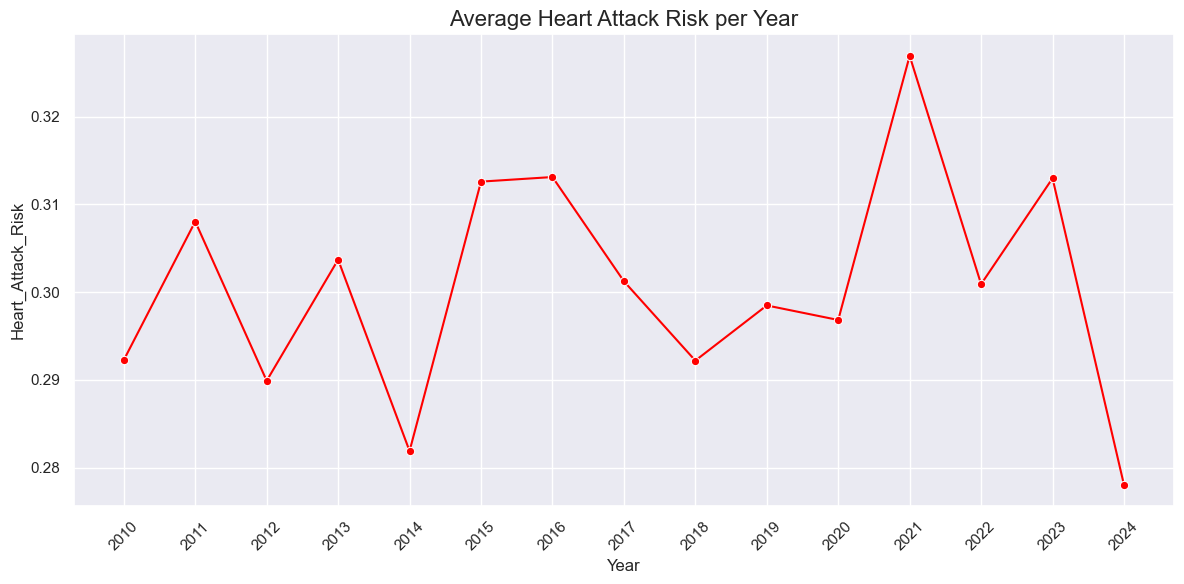

In [33]:
year_risk = df.groupby("Year")["Heart_Attack_Risk"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=year_risk, x="Year", y="Heart_Attack_Risk", marker="o" , color="red")
plt.title("Average Heart Attack Risk per Year", fontsize=16)
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

# 4️⃣ AGE TREND OVER YEARS

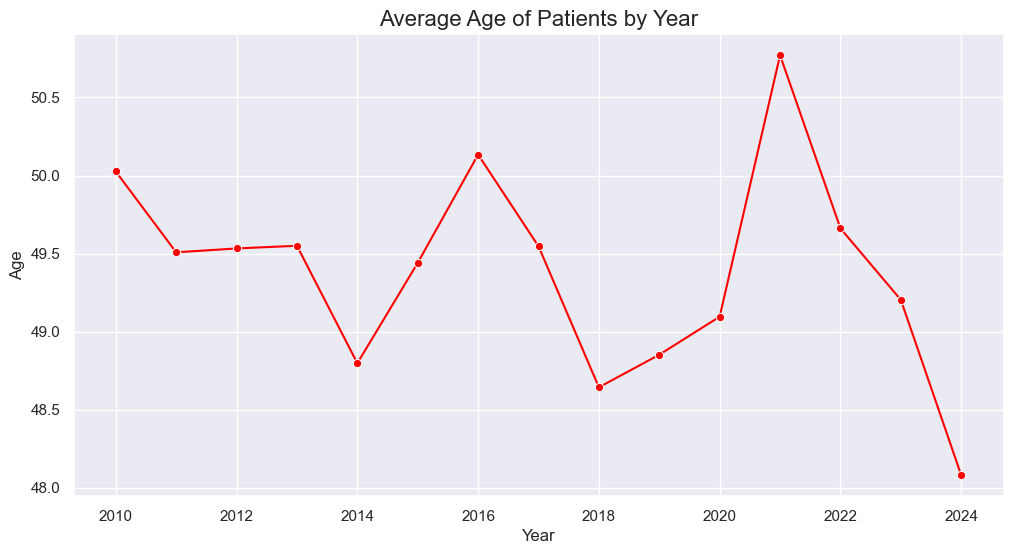

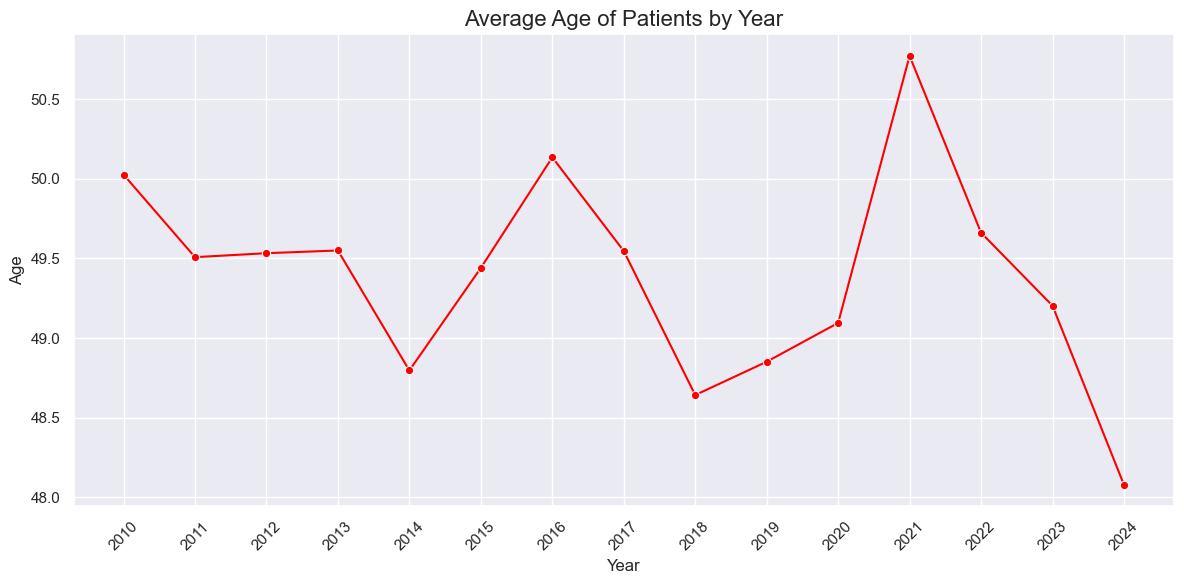

In [35]:
year_age = df.groupby("Year")["Age"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=year_age, x="Year", y="Age", marker="o", color="red")
plt.title("Average Age of Patients by Year", fontsize=16)
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

 # 5️⃣ YEAR-WISE HISTOGRAM OF HEART ATTACK RISK

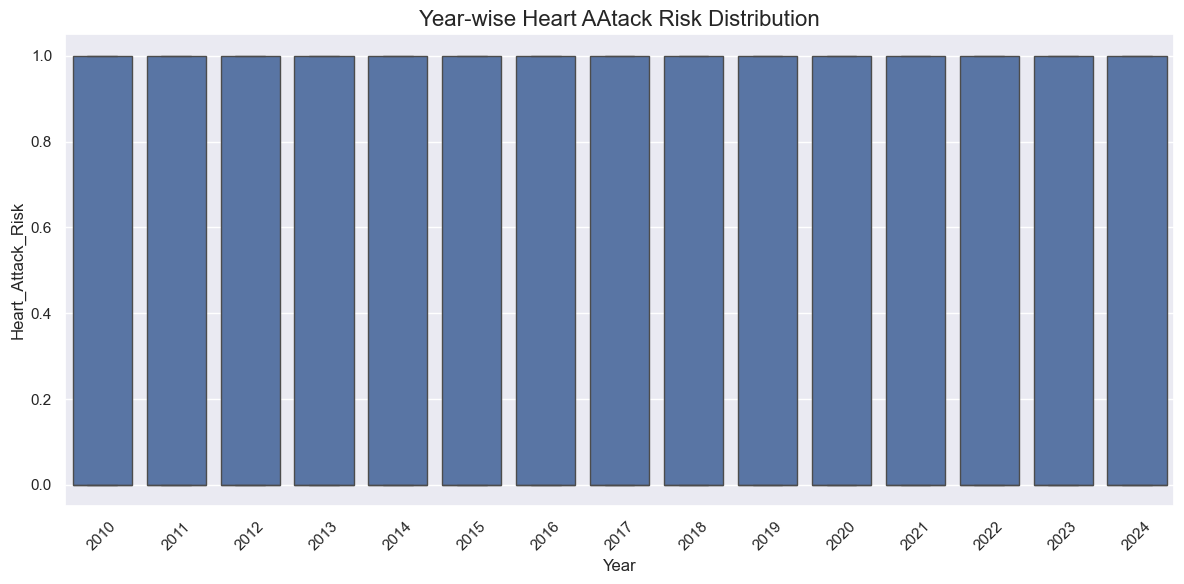

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Year", y="Heart_Attack_Risk")
plt.title("Year-wise Heart AAtack Risk Distribution", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6️⃣ STATE vs YEAR HEATMAP (Powerful)

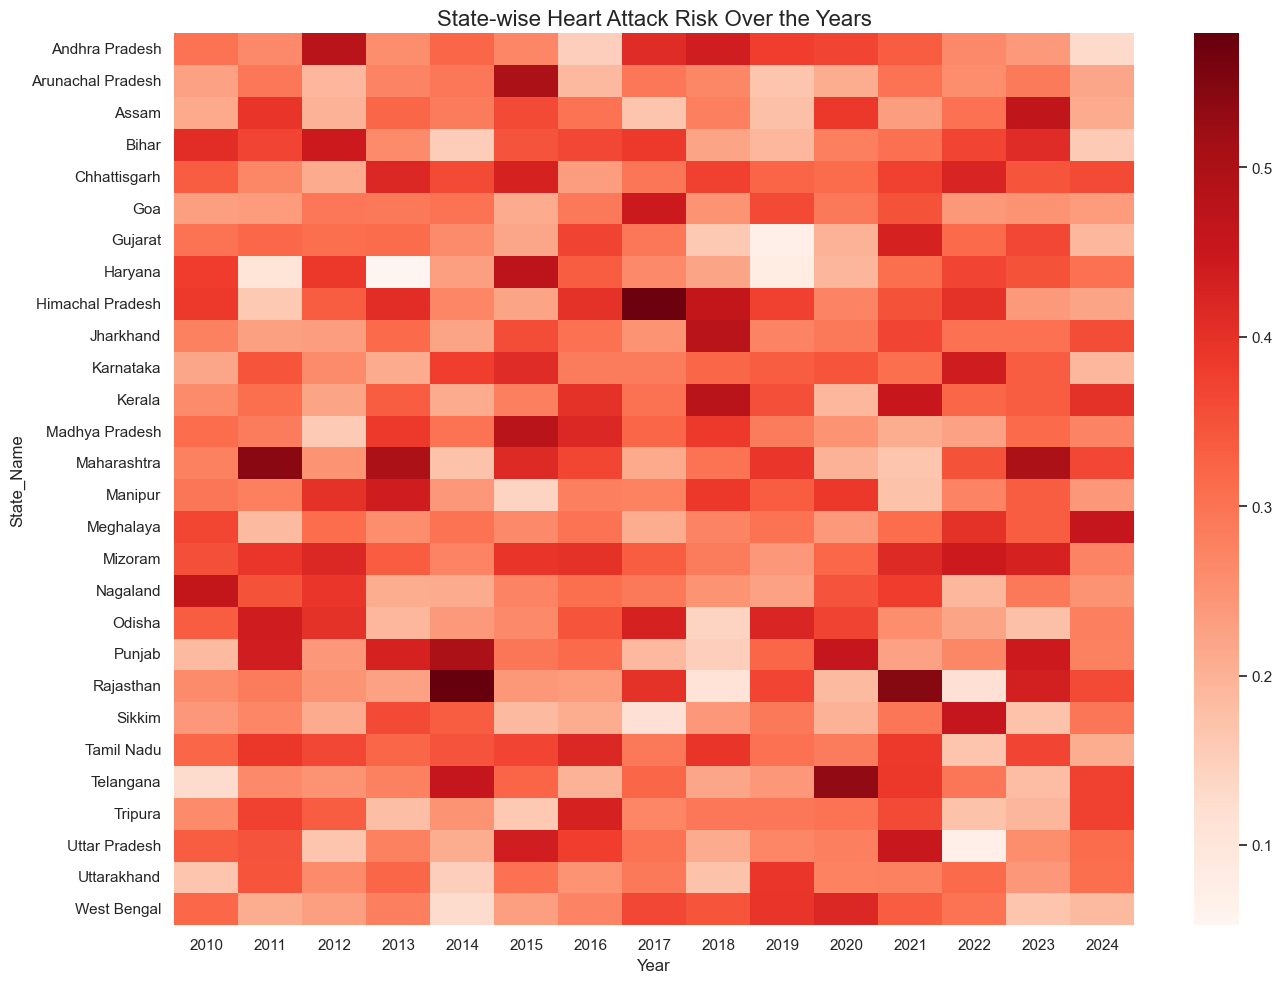

In [41]:
state_year = df.pivot_table(values="Heart_Attack_Risk",
                            index="State_Name",
                            columns="Year",
                            aggfunc="mean")
plt.figure(figsize=(14,10))
sns.heatmap(state_year, cmap="Reds")
plt.title("State-wise Heart Attack Risk Over the Years", fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# YEAR-BY-YEAR MACHINE LEARNING ANALYSIS
# ============================================

Year 2010: Accuracy = 0.6800, ROC-AUC = 0.5103
Year 2011: Accuracy = 0.7125, ROC-AUC = 0.5612
Year 2012: Accuracy = 0.7255, ROC-AUC = 0.6101
Year 2013: Accuracy = 0.6954, ROC-AUC = 0.5191
Year 2014: Accuracy = 0.7069, ROC-AUC = 0.5063
Year 2015: Accuracy = 0.6845, ROC-AUC = 0.5166
Year 2016: Accuracy = 0.7052, ROC-AUC = 0.5485
Year 2017: Accuracy = 0.6923, ROC-AUC = 0.4587
Year 2018: Accuracy = 0.7006, ROC-AUC = 0.4493
Year 2019: Accuracy = 0.6897, ROC-AUC = 0.5275
Year 2020: Accuracy = 0.6790, ROC-AUC = 0.4907
Year 2021: Accuracy = 0.6832, ROC-AUC = 0.5191
Year 2022: Accuracy = 0.7006, ROC-AUC = 0.4585
Year 2023: Accuracy = 0.7169, ROC-AUC = 0.5072
Year 2024: Accuracy = 0.6875, ROC-AUC = 0.4542


,Year,Accuracy,ROC_AUC
0,2010,0.680000,0.510303
1,2011,0.712500,0.561159
2,2012,0.725490,0.610092
3,2013,0.695402,0.519136
4,2014,0.706897,0.506297
5,2015,0.684524,0.516610
6,2016,0.705202,0.548537
7,2017,0.692308,0.458659
8,2018,0.700637,0.449275
9,2019,0.689655,0.527522


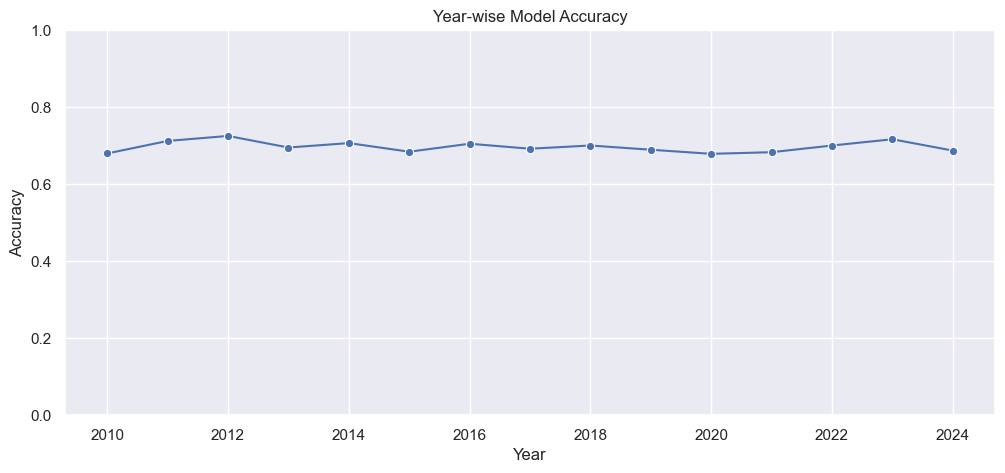

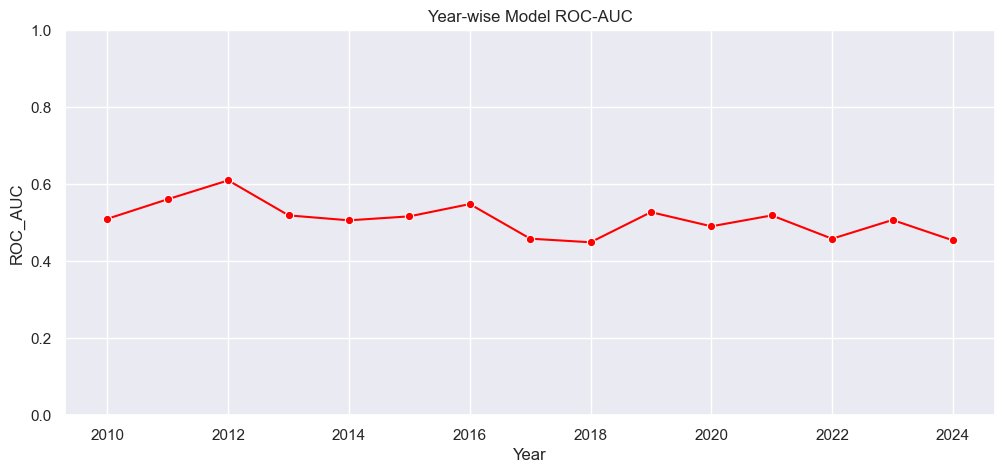

In [55]:
# ============================================
# YEAR-BY-YEAR MACHINE LEARNING ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Load dataset
df = pd.read_csv("heart_attack_prediction_india.csv")

# Ensure Year exists (2010–2024)
if "Year" not in df.columns:
    df["Year"] = np.random.choice(np.arange(2010, 2025), size=len(df), replace=True)

# -------------------------------
# Prepare storage
# -------------------------------
year_list = sorted(df["Year"].unique())
accuracies = []
rocs = []

# -------------------------------
# YEAR-WISE MODEL LOOP
# -------------------------------
for yr in year_list:

    df_year = df[df["Year"] == yr].copy()

    # Skip year if too few samples
    if len(df_year) < 30:
        print(f"Skipping year {yr} (not enough samples)")
        accuracies.append(None)
        rocs.append(None)
        continue

    # -----------------------
    # PREPROCESSING
    # -----------------------

    y = df_year["Heart_Attack_Risk"]

    X = df_year.drop(columns=["Heart_Attack_Risk", "State_Name", "Patient_ID", "Year"], errors="ignore")

    # Encode Gender
    if "Gender" in X.columns:
        X["Gender"] = X["Gender"].map({
            "Male": 1, "M": 1, "male": 1,
            "Female": 0, "F": 0, "female": 0
        }).fillna(0)

    # One-hot encode any remaining object columns
    X = pd.get_dummies(X, drop_first=True)

    X = X.fillna(X.median())

    # -----------------------
    # TRAIN-TEST SPLIT
    # -----------------------
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
    except:
        print(f"Skipping year {yr} (not enough class balance)")
        accuracies.append(None)
        rocs.append(None)
        continue

    # -----------------------
    # TRAIN MODEL
    # -----------------------
    model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # -----------------------
    # EVALUATE
    # -----------------------
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    rocs.append(roc)

    print(f"Year {yr}: Accuracy = {acc:.4f}, ROC-AUC = {roc:.4f}")

# -----------------------------------
# CREATE RESULTS DATAFRAME
# -----------------------------------
results = pd.DataFrame({
    "Year": year_list,
    "Accuracy": accuracies,
    "ROC_AUC": rocs
})

display(results)

# -----------------------------------
# PLOTS
# -----------------------------------

plt.figure(figsize=(12,5))
sns.lineplot(data=results, x="Year", y="Accuracy", marker="o")
plt.title("Year-wise Model Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
sns.lineplot(data=results, x="Year", y="ROC_AUC", marker="o", color="red")
plt.title("Year-wise Model ROC-AUC")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


# ============================================================
# YEAR-WISE 3D PLOT → Year × Age × Heart Attack Risk
# ============================================================


    Year        Age  Heart_Attack_Risk
0   2010  49.853107           0.310734
1   2011  49.232143           0.321429
2   2012  48.931186           0.323572
3   2013  50.347352           0.295950
4   2014  48.647709           0.301738
5   2015  48.578149           0.327769
6   2016  48.991329           0.291908
7   2017  49.199067           0.284603
8   2018  49.901903           0.263543
9   2019  49.131004           0.299854
10  2020  47.789086           0.302360
11  2021  50.605381           0.297459
12  2022  49.524194           0.264516
13  2023  49.843602           0.287520
14  2024  50.335244           0.332378


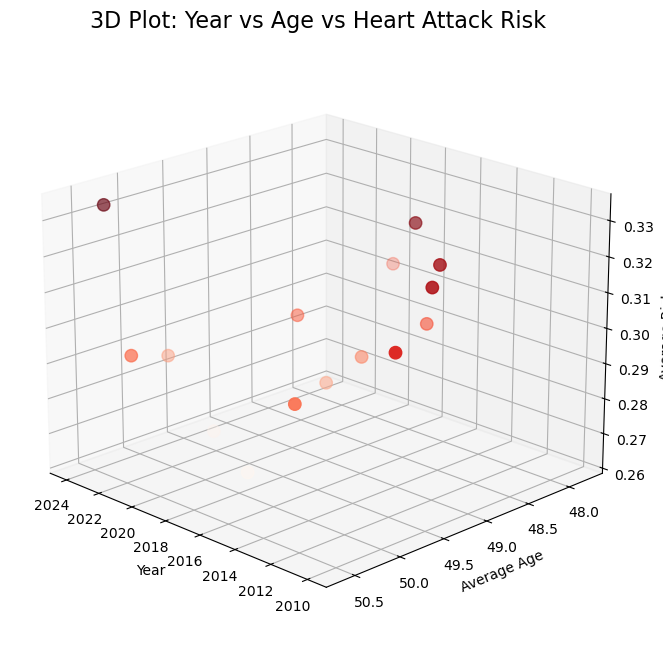

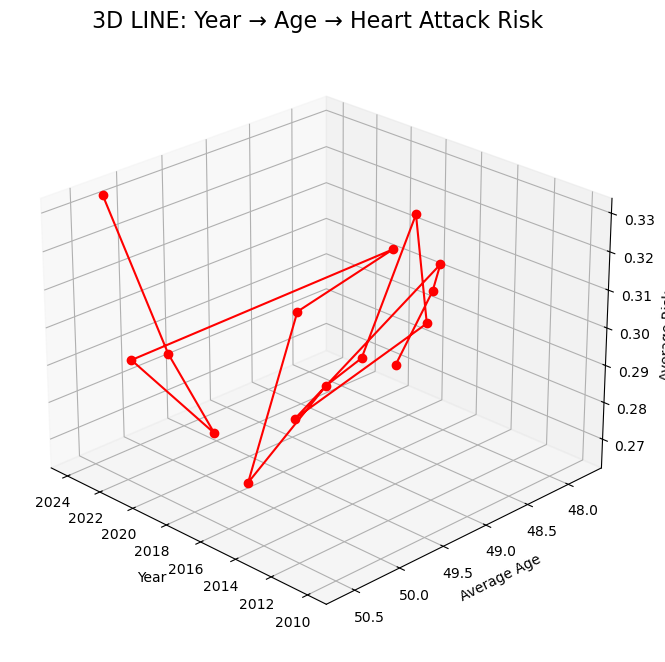

In [10]:
# ============================================================
# YEAR-WISE 3D PLOT → Year × Age × Heart Attack Risk
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Load data
df = pd.read_csv("heart_attack_prediction_india.csv")

# Ensure Year column exists (2010–2024)
if "Year" not in df.columns:
    df["Year"] = np.random.choice(np.arange(2010, 2025), size=len(df), replace=True)

# Group by Year → average Age & average Risk
year_data = df.groupby("Year").agg({
    "Age": "mean",
    "Heart_Attack_Risk": "mean"
}).reset_index()

print(year_data)

# -------------------------------
# 3D SCATTER PLOT
# -------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X = year_data["Year"]
Y = year_data["Age"]
Z = year_data["Heart_Attack_Risk"]

ax.scatter(X, Y, Z, c=Z, cmap='Reds', s=80)

ax.set_title("3D Plot: Year vs Age vs Heart Attack Risk", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Average Age")
ax.set_zlabel("Average Risk")

# Rotate view for better angle
ax.view_init(elev=20, azim=135)

plt.show()

# -------------------------------
# OPTIONAL: 3D LINE PLOT
# -------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X, Y, Z, marker='o', color='Red')

ax.set_title("3D LINE: Year → Age → Heart Attack Risk", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Average Age")
ax.set_zlabel("Average Risk")

ax.view_init(elev=25, azim=135)
plt.show()


# ============================================================
# 3D STATE-WISE PLOT → State × Year × Heart Attack Risk
# ============================================================


State Code Mapping: {0: 'Andhra Pradesh', 1: 'Arunachal Pradesh', 2: 'Assam', 3: 'Bihar', 4: 'Chhattisgarh', 5: 'Goa', 6: 'Gujarat', 7: 'Haryana', 8: 'Himachal Pradesh', 9: 'Jharkhand', 10: 'Karnataka', 11: 'Kerala', 12: 'Madhya Pradesh', 13: 'Maharashtra', 14: 'Manipur', 15: 'Meghalaya', 16: 'Mizoram', 17: 'Nagaland', 18: 'Odisha', 19: 'Punjab', 20: 'Rajasthan', 21: 'Sikkim', 22: 'Tamil Nadu', 23: 'Telangana', 24: 'Tripura', 25: 'Uttar Pradesh', 26: 'Uttarakhand', 27: 'West Bengal'}


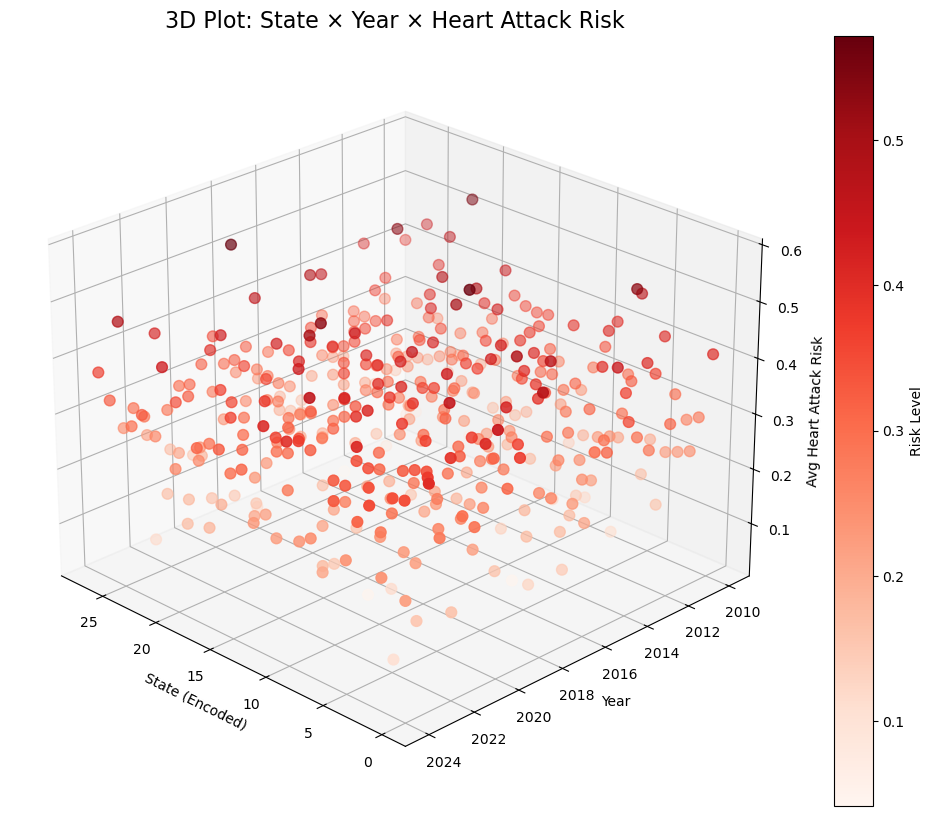

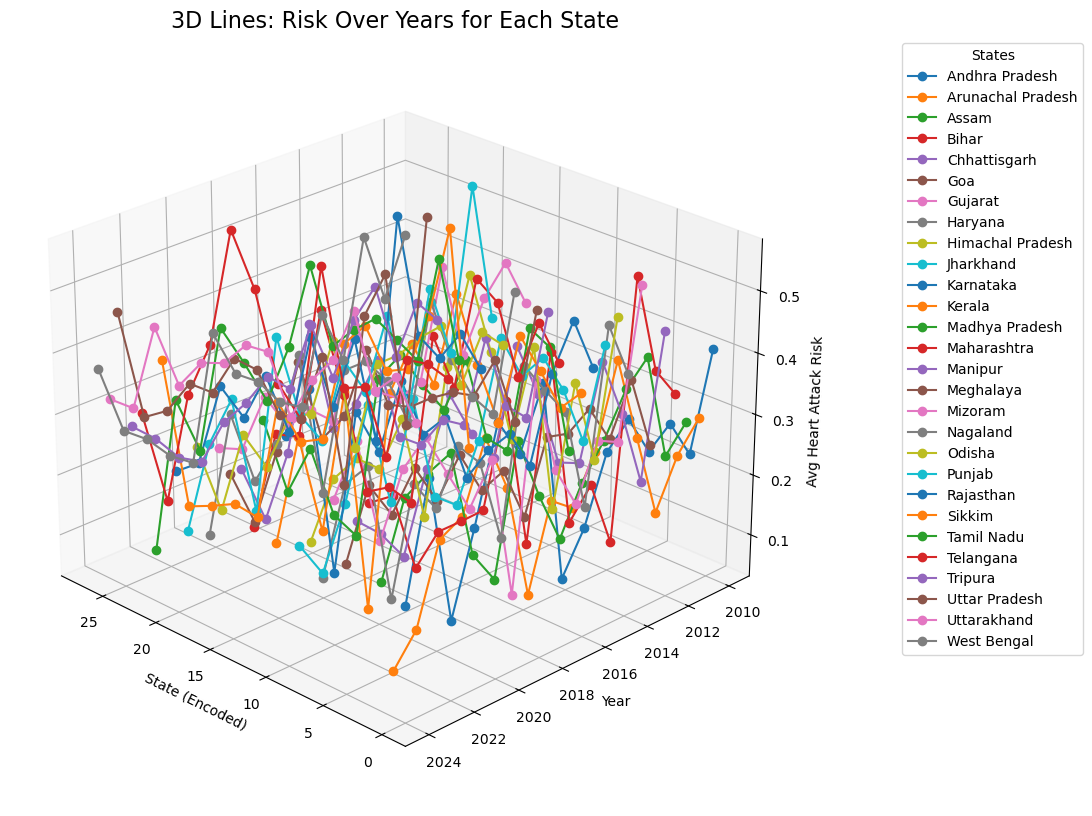

In [2]:
# ============================================================
# 3D STATE-WISE PLOT → State × Year × Heart Attack Risk
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Load dataset
df = pd.read_csv("heart_attack_prediction_india.csv")

# Ensure Year exists (2010–2024)
if "Year" not in df.columns:
    df["Year"] = np.random.choice(np.arange(2010, 2025), size=len(df), replace=True)

# -------------------------------------------
# PREPARE DATA
# -------------------------------------------

# Compute average risk per State per Year
state_year = df.groupby(["State_Name", "Year"])["Heart_Attack_Risk"].mean().reset_index()

# Encode state names → numeric axis values
state_year["State_Code"] = state_year["State_Name"].astype("category").cat.codes

# Save mapping (useful for labeling)
state_mapping = dict(enumerate(state_year["State_Name"].astype("category").cat.categories))

print("State Code Mapping:", state_mapping)

# -------------------------------------------
# 3D SCATTER PLOT
# -------------------------------------------

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

X = state_year["State_Code"]        # encoded state
Y = state_year["Year"]              # year
Z = state_year["Heart_Attack_Risk"] # avg risk

sc = ax.scatter(X, Y, Z, c=Z, cmap="Reds", s=60)

ax.set_title("3D Plot: State × Year × Heart Attack Risk", fontsize=16)
ax.set_xlabel("State (Encoded)")
ax.set_ylabel("Year")
ax.set_zlabel("Avg Heart Attack Risk")

# Rotate for better view
ax.view_init(elev=25, azim=135)

plt.colorbar(sc, label="Risk Level")
plt.show()

# -------------------------------------------
# OPTIONAL: 3D LINE PLOT PER STATE
# -------------------------------------------

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for state_code in state_year["State_Code"].unique():
    df_part = state_year[state_year["State_Code"] == state_code]
    ax.plot(df_part["State_Code"], df_part["Year"], df_part["Heart_Attack_Risk"],
            marker='o', label=state_mapping[state_code])

ax.set_title("3D Lines: Risk Over Years for Each State", fontsize=16)
ax.set_xlabel("State (Encoded)")
ax.set_ylabel("Year")
ax.set_zlabel("Avg Heart Attack Risk")

ax.view_init(elev=25, azim=135)
plt.legend(bbox_to_anchor=(1.15, 1), title="States")
plt.show()
